# Session 2: Homework 1

**Author:** Your name goes here

**Date:**


In [1]:
# Import required libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np                 # numpy is a comprehensive library with several mathematical functions
import yfinance as yf              # yfinance fetches stock data directly from Yahoo finance for use in projects
from datetime import datetime      # library with tools for manipulating & handling dates/times
import matplotlib.cm as cm         # colour palettes for visuals
import matplotlib.ticker as mtick  # used in building visuals
import warnings                    # this is used to control how warnings are handled in our project
from skimpy import skim            # Used for generating summary statistics of DataFrames


warnings.filterwarnings('ignore')  # we have decided to suppress all warning messages for this project

# Set style for better looking plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (6.75, 6.75)


# Analysis of movies- IMDB dataset

We will look at a subset sample of movies, taken from the [Kaggle IMDB 5000 movie dataset](https://www.kaggle.com/carolzhangdc/imdb-5000-movie-dataset)

In [2]:
# Load movies data

movies = pd.read_csv('../data/movies.csv')


# Printing out information of the dataset

print(movies.info())


# Printing the first few observations of the dataset

movies.head()

skim(movies)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2961 entries, 0 to 2960
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   title                2961 non-null   object 
 1   genre                2961 non-null   object 
 2   director             2961 non-null   object 
 3   year                 2961 non-null   int64  
 4   duration             2961 non-null   int64  
 5   gross                2961 non-null   int64  
 6   budget               2961 non-null   int64  
 7   cast_facebook_likes  2961 non-null   int64  
 8   votes                2961 non-null   int64  
 9   reviews              2961 non-null   int64  
 10  rating               2961 non-null   float64
dtypes: float64(1), int64(7), object(3)
memory usage: 254.6+ KB
None


╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 2961   │ │ int64       │ 7     │                                                          │
│ │ Number of columns │ 11     │ │ string      │ 3     │                                                          │
│ └───────────────────┴────────┘ │ float64     │ 1     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column      ┃ NA ┃ NA % ┃ mean     ┃ sd       ┃ p0   ┃ p25      ┃ p50      ┃ p75      ┃ p100      ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━┩  │
│ │ year        │  0 │    0 │     2003 │    9.946 │ 1920 │     1999 │     2004 │     2010 │      2016 │     ▃█ │  │
│ │ duration    │  0 │    0 │    109.6 │    22.17 │   37 │       95 │      106 │      119 │       330 │  ▁█▁   │  │
│ │ gross       │  0 │    0 │ 58090000 │ 72470000 │  703 │ 12280000 │ 34700000 │ 75590000 │ 760500000 │   █▁   │  │
│ │ budget      │  0 │    0 │ 40620000 │ 43680000 │  218 │ 11000000 │ 26000000 │ 55000000 │ 300000000 │  █▂▁   │  │
│ │ cast_facebo │  0 │    0 │    12390 │    20530 │    0 │     2241 │     4604 │    16930 │    656700 │   █    │  │
│ │ ok_likes    │    │      │          │          │      │          │          │          │           │        │  │
│ │ votes       │  0 │    0 │   109300 │   158100 │    5 │    19920 │    55750 │   133300 │   1690000 │   █▁   │  │
│ │ reviews     │  0 │    0 │    503.3 │    493.7 │    2 │      199 │      364 │      631 │      5312 │   █▁   │  │
│ │ rating      │  0 │    0 │    6.389 │    1.052 │  1.6 │      5.8 │      6.5 │      7.1 │       9.3 │   ▂█▆▁ │  │
│ └─────────────┴────┴──────┴──────────┴──────────┴──────┴──────────┴──────────┴──────────┴───────────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┓  │
│ ┃          ┃    ┃      ┃          ┃           ┃            ┃           ┃ chars per  ┃ words per ┃ total      ┃  │
│ ┃ column   ┃ NA ┃ NA % ┃ shortest ┃ longest   ┃ min        ┃ max       ┃ row        ┃ row       ┃ words      ┃  │
│ ┡━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━┩  │
│ │ title    │  0 │    0 │ O        │ Borat:    │ 10         │ xXx:      │       15.3 │       2.8 │       8262 │  │
│ │          │    │      │          │ Cultural  │ Cloverfiel │ State of  │            │           │            │  │
│ │          │    │      │          │ Learnings │ d Lane     │ the Union │            │           │            │  │
│ │          │    │      │          │ of        │            │           │            │           │            │  │
│ │          │    │      │          │ America   │            │           │            │           │            │  │
│ │          │    │      │          │ for Make  │            │           │            │           │            │  │
│ │          │    │      │          │ Benefit   │       

Besides the obvious variables of title, genre, director, year, and duration, the rest of the variables are as follows:

- gross : The gross earnings in the US box office, not adjusted for inflation

- budget: The movie's budget

- cast_facebook_likes: the number of facebook likes cast memebrs received

- votes: the number of people who voted for (or rated) the movie in IMDB

- reviews: the number of reviews for that movie

- rating: IMDB average rating

## Use your data import, inspection, and cleaning skills to answer the following:

### Missing values and duplicates

Are there any missing values (NAs)? Are all entries distinct or are there duplicate entries?

In [3]:
# Missing values and duplicates

# First, we calculate the total no. of missing values in our dataset's columns


# Next, we compute the total duplicates


### Count of movies by genre

Produce a table with the count of movies by genre, ranked in descending order.

In [4]:
# Count of movies by genre

# We want to the check the no. of observations for each genre


### Average gross, budget, and return on budget by genre

Produce a table with the average gross earning and budget (gross and budget) by genre. Calculate a variable return_on_budget which shows how many dollars did a movie make at the box office for each dollar of its budget. Rank genres by this return_on_budget in descending order.

In [ ]:
# Average gross, budget, and return on budget by genre




# Calculate return on budget by genre and show in descending order


### Top 15 directors by gross revenue

Produce a table that shows the top 15 directors who have created the highest gross revenue in the box office. Don't just show the total gross amount, but also the mean, median, and standard deviation per director.

In [ ]:
# Top 15 directors by gross revenue


### Ratings distribution by genre

Finally, ratings. Produce a table that describes how ratings are distributed by genre. We don't want just the mean, but also, min, max, median, SD and some kind of a histogram or density graph that visually shows how ratings are distributed.

In [ ]:
# Ratings distribution by genre


In [ ]:
# Histogram of ratings by genre

# filter for genres that have at least 5 movies


# plot all the histograms together instead of one after another, using seaborn's facet grid



## Use `seaborn` to answer the following:

### Gross vs. cast Facebook likes

-   Examine the relationship between `gross` and `cast_facebook_likes`. Produce a scatterplot and write one sentence discussing whether the number of facebook likes that the cast has received is likely to be a good predictor of how much money a movie will make at the box office. What variable are you going to map to the Y- and X- axes?

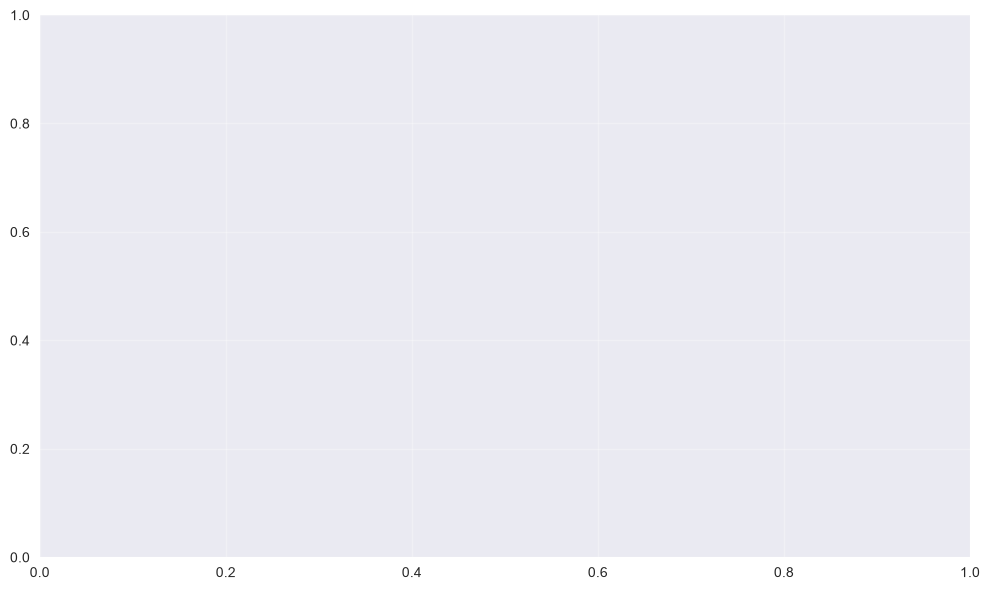

NameError: name 'correlation' is not defined

In [5]:
# Scatter plot: Gross vs Cast Facebook Likes

# Set the figure size using matplotlib. Seaborn plots are drawn on a matplotlib figure.
plt.figure(figsize=(10, 6))

# Use seaborn.regplot() to create the scatter plot and the linear regression line.
# It automatically:
#   1. Draws a scatter plot of the x and y variables.
#   2. Estimates and plots a linear regression model relating x and y.
#   3. Adds a shaded 95% confidence interval around the regression line.


# Add a grid for easier reading of values.
plt.grid(True, alpha=0.3)

# Ensure all plot elements are displayed correctly without overlapping.
plt.tight_layout()

# Display the plot.
plt.show()

# --- Correlation Calculation ---
# Calculate the Pearson correlation coefficient.

# Print the result formatted to three decimal places.
print(f"Correlation between gross and cast facebook likes: {correlation:.3f}")

### Gross vs. budget

-   Examine the relationship between `gross` and `budget`. Produce a scatterplot and write one sentence discussing whether budget is likely to be a good predictor of how much money a movie will make at the box office.

In [2]:
# Scatter plot: Gross vs Budget



### Gross vs. rating, faceted by genre

-   Examine the relationship between `gross` and `rating`. Produce a scatterplot, faceted by `genre` and discuss whether IMDB ratings are likely to be a good predictor of how much money a movie will make at the box office. Is there anything strange in this dataset?

In [3]:
# Scatter plot: Gross vs Rating by Genre- for genres that have at least 5 movies





# Returns of financial stocks

> You may find useful the material on [finance data sources](https://am01-sep24.netlify.app/reference/finance_data/).

We will use the `yfinance` package to download historical data of stock prices, calculate returns, and examine the distribution of returns.

We must first identify which stocks we want to download data for, and for this we must know their ticker symbol; Apple is known as AAPL, Microsoft as MSFT, McDonald's as MCD, etc. The file `nyse.csv` contains 508 stocks listed on the NYSE, their ticker `symbol`, `name`, the IPO (Initial Public Offering) year, and the sector and industry the company is in.



In [6]:
# Load NYSE data

# Load the dataset from the relevant directory
nyse = pd.read_csv('../data/nyse.csv')

# Printing out the first 10 observations
nyse.head()

# Printing out information of the dataset's variables
print("nData info: ")

nyse.info()

nData info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   symbol         508 non-null    object 
 1   name           508 non-null    object 
 2   ipo_year       143 non-null    float64
 3   sector         508 non-null    object 
 4   industry       508 non-null    object 
 5   summary_quote  508 non-null    object 
dtypes: float64(1), object(5)
memory usage: 23.9+ KB


## Companies per sector

Based on this dataset, create a table and a bar plot that shows the number of companies per sector, in descending order

In [8]:
# Companies per sector




# Bar plot





## Choose stocks and download data

Next, let's choose some stocks and their ticker symbols and download some data. You **MUST** choose 6 different stocks from the ones listed below; You should, however, add `SPY` which is the SP500 ETF (Exchange Traded Fund).

In [7]:
# Download stock data

# The 6 chosen stocks plus SPY (the S&P 500 ETF)
my_stocks = ["AAPL", "JPM", "DIS", "DPZ", "ANF", "XOM", "SPY"]

# Date range: start on 1 January five years ago, end today.
# Computed from today's date so it always stays current when re-run.
end_date = pd.Timestamp.today().normalize()
start_date = pd.Timestamp(year=end_date.year - 5, month=1, day=1)

# Download every ticker in ONE call. Passing a list to yf.download returns a
# frame with a two-level column index (field, ticker); selecting "Adj Close"
# collapses it to a tidy price matrix: dates on the index, one column per stock.
prices = yf.download(
    my_stocks,
    start=start_date,
    end=end_date,
    auto_adjust=False,   # keep the explicit "Adj Close" column
    progress=False,
)["Adj Close"]

# yfinance returns the columns alphabetically, so reorder to match our list.
prices = prices[my_stocks]

print(f"Downloaded {start_date.date()} to {end_date.date()}")
print("Adjusted-close price matrix:", prices.shape)   # (trading days, stocks)
prices.head()

Downloaded 2021-01-01 to 2026-08-25
Adjusted-close price matrix: (1416, 7)


Ticker,AAPL,JPM,DIS,DPZ,ANF,XOM,SPY
Date,,,,,,,
2021-01-04,125.632507,109.000519,172.271988,352.243988,20.490000,33.251339,342.436920
2021-01-05,127.185814,109.593643,173.008865,353.951874,21.370001,34.853786,344.795441
2021-01-06,122.904533,114.739685,173.668152,357.228333,22.240000,35.743168,346.856812
2021-01-07,127.098427,118.507637,173.144592,355.668945,21.209999,36.023605,352.010162
2021-01-08,128.195465,118.638474,173.251266,360.903931,21.530001,36.424232,354.015900


## Calculate daily and monthly returns

Financial performance analysis depend on returns; If I buy a stock today for 100 and I sell it tomorrow for 101.75, my one-day return, assuming no transaction costs, is 1.75%. So given the adjusted closing prices, our first step is to calculate daily and monthly returns.

In [8]:
# Calculate returns

# pct_change() on the whole DataFrame computes returns for every stock at once.
daily_returns = prices.pct_change()

# Resample to month-end ("ME") / year-end ("YE"), take the last price in each
# period, then compute the percentage change. (Older pandas uses "M" / "Y".)
monthly_returns = prices.resample("ME").last().pct_change()
yearly_returns  = prices.resample("YE").last().pct_change()

monthly_returns.head()

Ticker,AAPL,JPM,DIS,DPZ,ANF,XOM,SPY
Date,,,,,,,
2021-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-28,-0.079712,0.143779,0.124101,-0.065406,0.186389,0.233125,0.027805
2021-03-31,0.007340,0.034382,-0.023910,0.064204,0.253562,0.026853,0.045399
2021-04-30,0.076218,0.016330,0.008129,0.148318,0.092684,0.025255,0.052911
2021-05-31,-0.050497,0.067811,-0.039619,0.010726,0.138970,0.034597,0.006566


## Summary of monthly returns

Create a table where you summarise monthly returns for each of the stocks and `SPY`; min, max, median, mean, SD.

In [16]:
# Summary of monthly returns

# .agg() applies all five statistics to every column in one shot; .T puts the
# stocks on the rows and the statistics on the columns.
monthly_summary = (
    monthly_returns
    .agg(["min", "max", "median", "mean", "std"])
    .T
    .round(4)
)

print("Monthly returns summary:")
monthly_summary

Monthly returns summary:


,min,max,median,mean,std
Ticker,,,,,
AAPL,-0.1223,0.1886,0.0175,0.0157,0.0711
JPM,-0.1484,0.2154,0.0234,0.0196,0.0680
DIS,-0.1861,0.2487,-0.0107,-0.0016,0.0935
DPZ,-0.1944,0.1773,-0.0027,0.0044,0.0925
ANF,-0.4089,0.4226,0.0487,0.0376,0.1680
XOM,-0.1291,0.2692,0.0253,0.0259,0.0803
SPY,-0.0924,0.1051,0.0210,0.0129,0.0439


## Density plot of monthly returns

Plot a density plot, using `sns.kdeplot()`, for each of the stocks

Text(0.5, 1.02, 'Density of Monthly Returns by Stock')

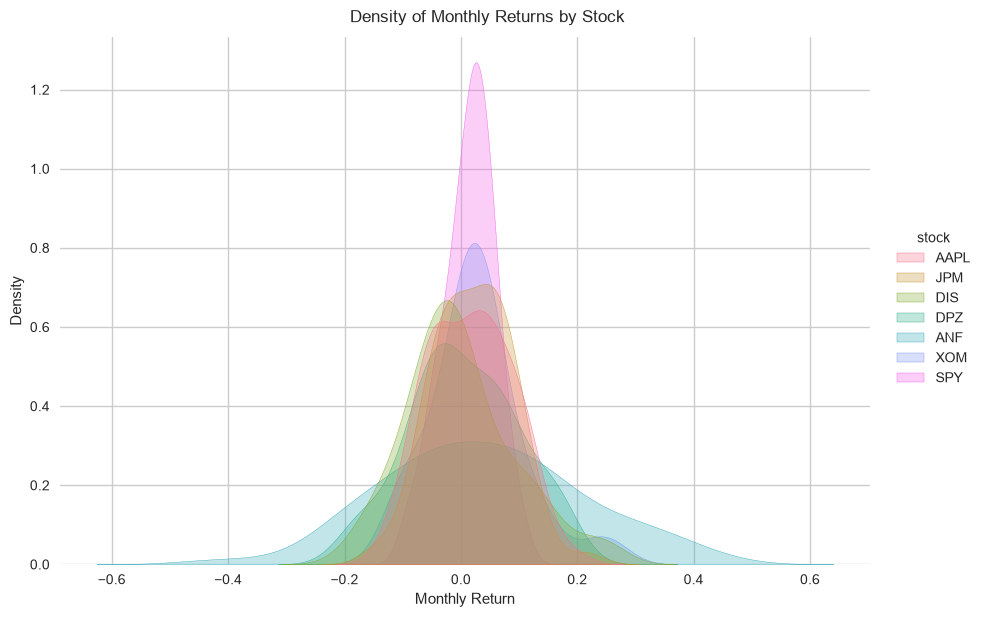

In [17]:
# Density plot of monthly returns

# Reshape to long ("tidy") form so seaborn can colour by stock with `hue`:
# one row per (date, stock, monthly_return).
monthly_long = (
    monthly_returns
    .melt(value_name="monthly_return", var_name="stock", ignore_index=False)
    .dropna()
)

sns.set_style("whitegrid")

# displot draws every stock's KDE on a single seaborn figure, no manual loop.
g = sns.displot(
    data=monthly_long,
    x="monthly_return",
    hue="stock",
    kind="kde",
    fill=True,
    alpha=0.3,
    height=6,
    aspect=1.5,
)
g.set_axis_labels("Monthly Return", "Density")
g.fig.suptitle("Density of Monthly Returns by Stock", y=1.02)

What can you infer from this plot? Which stock is the riskiest? The least risky?

> TYPE YOUR ANSWER AFTER (AND OUTSIDE!) THIS BLOCKQUOTE.

## Risk-return plot

Finally, make a plot that shows the expected monthly return (mean) of a stock on the Y axis and the risk (standard deviation) in the X-axis. Please use `plt.annotate()` to label each stock

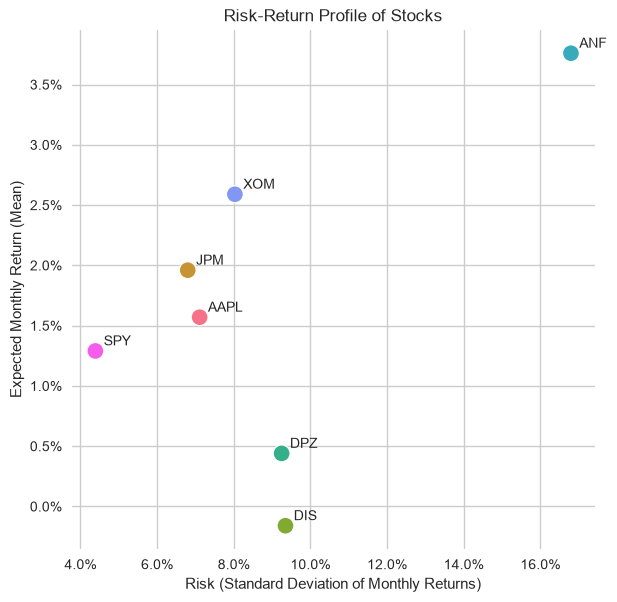

In [19]:
# Risk-return plot
# monthly_summary already holds each stock's mean (return) and std (risk),
# so we can plot straight from it. reset_index turns the ticker into a column.
risk_return = monthly_summary.reset_index(names="stock")

sns.set_style("whitegrid")
ax = sns.scatterplot(
    data=risk_return,
    x="std",
    y="mean",
    hue="stock",
    s=150,
    legend=False,
)

# Label each point, one annotation per row.
for row in risk_return.itertuples():
    ax.annotate(row.stock, (row.std, row.mean),
                xytext=(6, 4), textcoords="offset points")

ax.set(
    xlabel="Risk (Standard Deviation of Monthly Returns)",
    ylabel="Expected Monthly Return (Mean)",
    title="Risk-Return Profile of Stocks",
)

# Format both axes as percentages with one decimal (values are decimals, so xmax=1).
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))

What can you infer from this plot? Are there any stocks which, while being riskier, do not have a higher expected return?

> TYPE YOUR ANSWER AFTER (AND OUTSIDE!) THIS BLOCKQUOTE

# Rents in San Francisco 2000-2018

[Kate Pennington](https://www.katepennington.org/data) created a panel of historic Craigslist rents by scraping posts archived by the Wayback Machine. You can read more about her work here:

[What impact does new housing have on rents, displacement, and gentrification in the surrounding neighborhood? Read our interview with economist Kate Pennington about her article, \"Does Building New Housing Cause Displacement?:The Supply and Demand Effects of Construction in San Francisco.\"](https://matrix.berkeley.edu/research-article/kate-pennington-on-gentrification-and-displacement-in-san-francisco/)

In our case, we have a clean(ish) dataset with about 200K rows that correspond to Craigslist listings for renting properties in the greater SF area. The data dictionary is as follows:

| variable    | class     | description           |
|-------------|-----------|-----------------------|
| post_id     | character | Unique ID             |
| date        | double    | date                  |
| year        | double    | year                  |
| nhood       | character | neighborhood          |
| city        | character | city                  |
| county      | character | county                |
| price       | double    | price in USD          |
| beds        | double    | n of beds             |
| baths       | double    | n of baths            |
| sqft        | double    | square feet of rental |
| room_in_apt | double    | room in apartment     |
| address     | character | address               |
| lat         | double    | latitude              |
| lon         | double    | longitude             |
| title       | character | title of listing      |
| descr       | character | description           |
| details     | character | additional details    |

The dataset was used in a recent [tidyTuesday](https://github.com/rfordatascience/tidytuesday) project.

In [20]:
# Download rent data

rent = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2022/2022-07-05/rent.csv')

print("Data shape:", rent.shape)

print("\nData info:")

# Printing the dataset's variables, their data types etc.
print(rent.info())

Data shape: (200796, 17)

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200796 entries, 0 to 200795
Data columns (total 17 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   post_id      200796 non-null  object 
 1   date         200796 non-null  int64  
 2   year         200796 non-null  int64  
 3   nhood        200796 non-null  object 
 4   city         200796 non-null  object 
 5   county       199402 non-null  object 
 6   price        200796 non-null  int64  
 7   beds         194188 non-null  float64
 8   baths        42675 non-null   float64
 9   sqft         64679 non-null   float64
 10  room_in_apt  200796 non-null  int64  
 11  address      3908 non-null    object 
 12  lat          7651 non-null    float64
 13  lon          4312 non-null    float64
 14  title        198279 non-null  object 
 15  descr        3254 non-null    object 
 16  details      8016 non-null    object 
dtypes: float64(5), int64(4), objec

## Variable types and missing values

What are the variable types? Do they all correspond to what they really are? Which variables have most missing values?

In [9]:
# Data inspection

# Calculating the total no. of missing values in each column of the dataset


# Sorts variables with missing values in ascending order

# Printing out the datatypes


# Printing out a sample- the first few rows



## Top 20 cities by % of listings

Make a plot that shows the top 20 cities in terms of % of classifieds between 2000-2018. You need to calculate the number of listings by city, and then convert that number to a %.

The final graph should look like this:

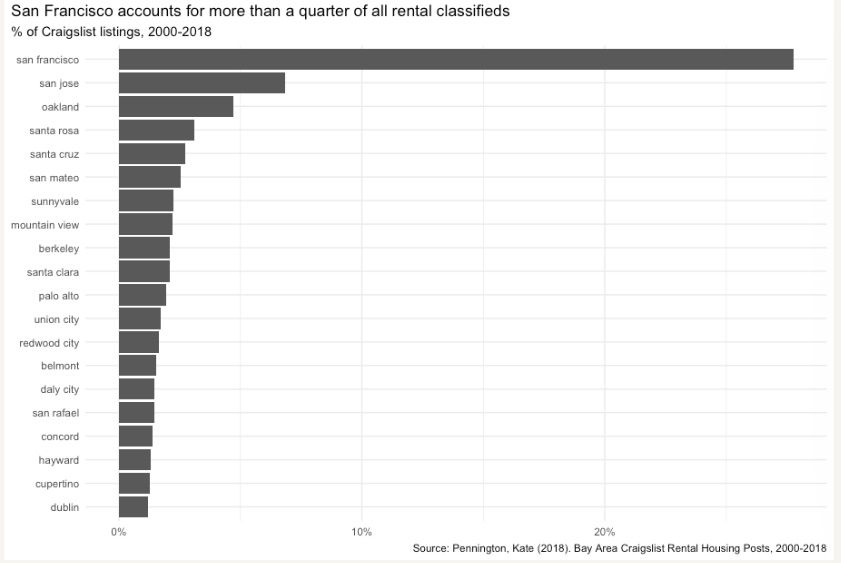

In [11]:
# Top 20 cities by percentage of listings



## Median prices in San Francisco by bedrooms

Make a plot that shows the evolution of median prices in San Francisco for 0, 1, 2, and 3 bedrooms listings. The final graph should resemble this

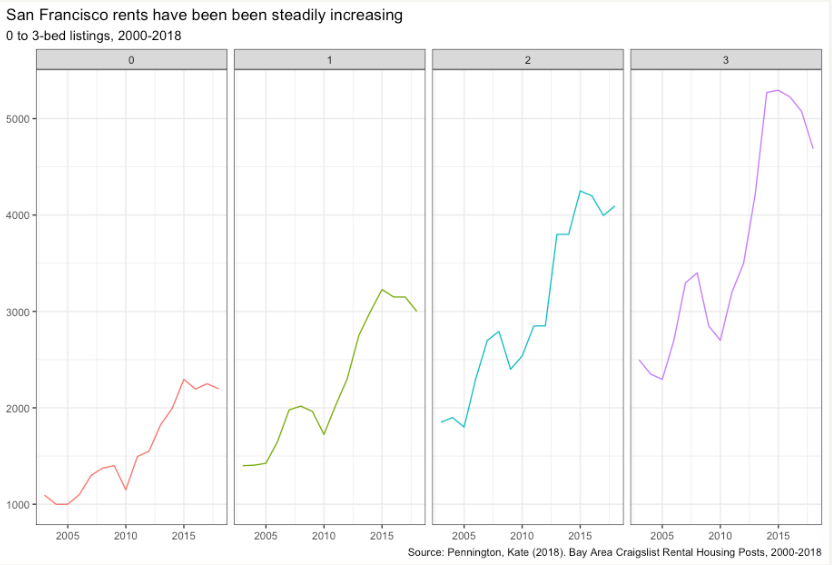

In [12]:
# Time-series of median rents in San Francisco (0-3 bedrooms)

# Data Prep



## Median rents for the top 12 Bay Area cities

Finally, make a plot that shows median rental prices for the top 12 cities in the Bay area (for 1 bedroom rentals). Your final graph should look like this

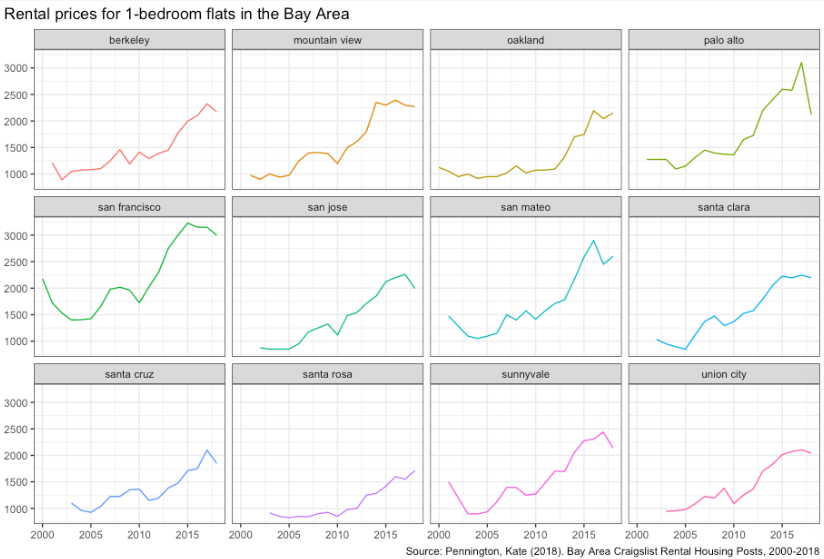

In [13]:
# Median rental prices for top 12 cities (in terms of number of ads) in Bay Area



What can you infer from these plots? Don't just explain what's in the graph, but speculate or tell a short story (1-2 paragraphs max).

> TYPE YOUR ANSWER AFTER (AND OUTSIDE!) THIS BLOCKQUOTE.

# Deliverables

There is a lot of explanatory text, comments, etc. You do not need these, so delete them and produce a stand-alone document that you could share with someone. Save this notebook and upload it to Canvas.

# Details

-   Who did you collaborate with: TYPE NAMES HERE
-   Approximately how much time did you spend on this problem set: ANSWER HERE
-   What, if anything, gave you the most trouble: ANSWER HERE


**Please seek out help when you need it,** and remember the 15-minute rule. You know enough Python (and have enough examples of code from class and your readings) to be able to do this. If you get stuck, ask for help from others, use LLMs at your own risk-- and remember that I am here to help too!

> As a true test to yourself, do you understand the code you submitted and are you able to explain it to someone else?


# Rubric

Check minus (1/5): Displays minimal effort. Doesn't complete all components. Code is poorly written and not documented. Uses the same type of plot for each graph, or doesn't use plots appropriate for the variables being analyzed.

Check (3/5): Solid effort. Hits all the elements. No clear mistakes. Easy to follow (both the code and the output).

Check plus (5/5): Finished all components of the assignment correctly and addressed both challenges. Code is well-documented (both self-documented and with additional comments as necessary). Used pandas with command chaining and seaborn, instead of matplotlib. Graphs and tables are properly labelled. Analysis is clear and easy to follow, either because graphs are labeled clearly or you've written additional text to describe how you interpret the output.